Imports


In [1]:
import McsPy

In [3]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

import os
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# MCS PyData tools
import McsPy
import McsPy.McsData
from McsPy import ureg, Q_

# VISUALIZATION TOOLS
import matplotlib.pyplot as plt
%matplotlib inline

# SUPRESS WARNINGS
import warnings
warnings.filterwarnings('ignore')

# autoreload modules
%load_ext autoreload
%autoreload 2

# import bombcell module
#import bombcell as bc

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import sys
from pathlib import Path
from pprint import pprint 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [6]:
from modules.filters import lowpass_filter, bandpass_filter

Functions

In [7]:
def plot_analog_stream_channel(analog_stream, channel_idx, from_in_s=0, to_in_s=None, show=True):
    """
    Plots data from a single AnalogStream channel
    
    :param analog_stream: A AnalogStream object
    :param channel_idx: A scalar channel index (0 <= channel_idx < # channels in the AnalogStream)
    :param from_in_s: The start timestamp of the plot (0 <= from_in_s < to_in_s). Default: 0
    :param to_in_s: The end timestamp of the plot (from_in_s < to_in_s <= duration). Default: None (= recording duration)
    :param show: If True (default), the plot is directly created. For further plotting, use show=False
    """
    # extract basic information
    ids = [c.channel_id for c in analog_stream.channel_infos.values()]
    channel_id = ids[channel_idx]
    channel_info = analog_stream.channel_infos[channel_id]
    sampling_frequency = channel_info.sampling_frequency.magnitude
   
    # get start and end index
    from_idx = max(0, int(from_in_s * sampling_frequency))
    if to_in_s is None:
        to_idx = analog_stream.channel_data.shape[1]
    else:
        to_idx = min(analog_stream.channel_data.shape[1], int(to_in_s * sampling_frequency))
        
    # get the timestamps for each sample
    time = analog_stream.get_channel_sample_timestamps(channel_id, from_idx, to_idx)

    # scale time to seconds:
    scale_factor_for_second = Q_(1,time[1]).to(ureg.s).magnitude
    time_in_sec = time[0] * scale_factor_for_second
    
    # get the signal
    signal = analog_stream.get_channel_in_range(channel_id, from_idx, to_idx)

    # scale signal to µV:
    scale_factor_for_uV = Q_(1,signal[1]).to(ureg.uV).magnitude
    signal_in_uV = signal[0] * scale_factor_for_uV

    # construct the plot
    _ = plt.figure(figsize=(20,6))
    _ = plt.plot(time_in_sec, signal_in_uV)
    _ = plt.xlabel('Time (%s)' % ureg.s)
    _ = plt.ylabel('Voltage (%s)' % ureg.uV)
    _ = plt.title('Channel %s' % channel_info.info['Label'])
    if show:
        plt.show()

In [8]:
def extract_waveforms(signal, fs, spikes_idx, pre, post):
    """
    Extract spike waveforms as signal cutouts around each spike index as a spikes x samples numpy array
    
    :param signal: The signal as a 1-dimensional numpy array
    :param fs: The sampling frequency in Hz
    :param spikes_idx: The sample index of all spikes as a 1-dim numpy array
    :param pre: The duration of the cutout before the spike in seconds
    :param post: The duration of the cutout after the spike in seconds
    """
    cutouts = []
    pre_idx = int(pre * fs)
    post_idx = int(post * fs)
    for index in spikes_idx:
        if index-pre_idx >= 0 and index+post_idx <= signal.shape[0]:
            cutout = signal[(index-pre_idx):(index+post_idx)]
            cutouts.append(cutout)
    return np.stack(cutouts)

In [9]:
def detect_threshold_crossings(signal, fs, threshold, dead_time):
    """
    Detect threshold crossings in a signal with dead time and return them as an array
    
    The signal transitions from a sample above the threshold to a sample below the threshold for a detection and
    the last detection has to be more than dead_time apart from the current one.
    
    :param signal: The signal as a 1-dimensional numpy array
    :param fs: The sampling frequency in Hz
    :param threshold: The threshold for the signal
    :param dead_time: The dead time in seconds. 
    """
    dead_time_idx = dead_time * fs
    threshold_crossings = np.diff((signal <= threshold).astype(int) > 0).nonzero()[0]
    distance_sufficient = np.insert(np.diff(threshold_crossings) >= dead_time_idx, 0, True)
    while not np.all(distance_sufficient):
        # repeatedly remove all threshold crossings that violate the dead_time
        threshold_crossings = threshold_crossings[distance_sufficient]
        distance_sufficient = np.insert(np.diff(threshold_crossings) >= dead_time_idx, 0, True)
    return threshold_crossings

def get_next_minimum(signal, index, max_samples_to_search):
    """
    Returns the index of the next minimum in the signal after an index
    
    :param signal: The signal as a 1-dimensional numpy array
    :param index: The scalar index 
    :param max_samples_to_search: The number of samples to search for a minimum after the index
    """
    search_end_idx = min(index + max_samples_to_search, signal.shape[0])
    min_idx = np.argmin(signal[index:search_end_idx])
    return index + min_idx

def align_to_minimum(signal, fs, threshold_crossings, search_range):
    """
    Returns the index of the next negative spike peak for all threshold crossings
    
    :param signal: The signal as a 1-dimensional numpy array
    :param fs: The sampling frequency in Hz
    :param threshold_crossings: The array of indices where the signal crossed the detection threshold
    :param search_range: The maximum duration in seconds to search for the minimum after each crossing
    """
    search_end = int(search_range*fs)
    aligned_spikes = [get_next_minimum(signal, t, search_end) for t in threshold_crossings]
    return np.array(aligned_spikes)

In [10]:
def plot_waveforms(cutouts, fs, pre, post, n=100, color='k', show=True):
    """
    Plot an overlay of spike cutouts
    
    :param cutouts: A spikes x samples array of cutouts
    :param fs: The sampling frequency in Hz
    :param pre: The duration of the cutout before the spike in seconds
    :param post: The duration of the cutout after the spike in seconds
    :param n: The number of cutouts to plot, or None to plot all. Default: 100
    :param color: The line color as a pyplot line/marker style. Default: 'k'=black
    :param show: Set this to False to disable showing the plot. Default: True
    """
    if n is None:
        n = cutouts.shape[0]
    n = min(n, cutouts.shape[0])
    time_in_us = np.arange(-pre*1000, post*1000, 1e3/fs)
    if show:
        _ = plt.figure(figsize=(12,6))
    
    for i in range(n):
        _ = plt.plot(time_in_us, cutouts[i,]*1e6, color, linewidth=1, alpha=0.3)
        _ = plt.xlabel('Time (%s)' % ureg.ms)
        _ = plt.ylabel('Voltage (%s)' % ureg.uV)
        _ = plt.title('Cutouts')
    
    if show:
        plt.show()

Analyze and Visualize HDF files

In [16]:
# NOTE: for now this only takes HDF files as input but it would
# be nice if it could get the raw files too
FILE_PATH = "C:/Users/Ines/Documents/Multi Channel DataManager/2025/SciLifeLab/08.09.25 - Anna Herland/2025-09-08T13-10-30AH-BrainOrganoid-Brainphys-10 min_B-00023.h5"
file = file = McsPy.McsData.RawData(FILE_PATH)
electrode_stream = file.recordings[0].analog_streams[0]

Recording_0 <HDF5 group "/Data/Recording_0" (1 members)>
Stream_0 <HDF5 group "/Data/Recording_0/AnalogStream/Stream_0" (3 members)>
ChannelData <HDF5 dataset "ChannelData": shape (60, 2406000), type "<i4">
ChannelDataTimeStamps <HDF5 dataset "ChannelDataTimeStamps": shape (1, 3), type "<i8">
InfoChannel <HDF5 dataset "InfoChannel": shape (60,), type "|V108">


In [40]:
# Check the labels for each index of the stream
CHANNEL_NMR = 46
channel_index = 0
for i in range(0,60):
    temp = electrode_stream.channel_infos[i]
    channel_number = temp.info['Label'][-2:]
    print(f"index: {i}, channel number: {channel_number}")
    if(channel_number!="ef"):
        if(CHANNEL_NMR == int(channel_number)):
            channel_index = i
            break

print(f"The index chosen is, {channel_index}")




index: 0, channel number: 47
index: 1, channel number: 48
index: 2, channel number: 46
The index chosen is, 2


c:\Users\Ines\anaconda3\envs\scilife-env\Lib\site-packages\McsPy\McsData.py:534: DeprecationWarning: Calling the getitem method from a UnitRegistry will be removed in future versions of pint.
use `parse_expression` method or use the registry as a callable.


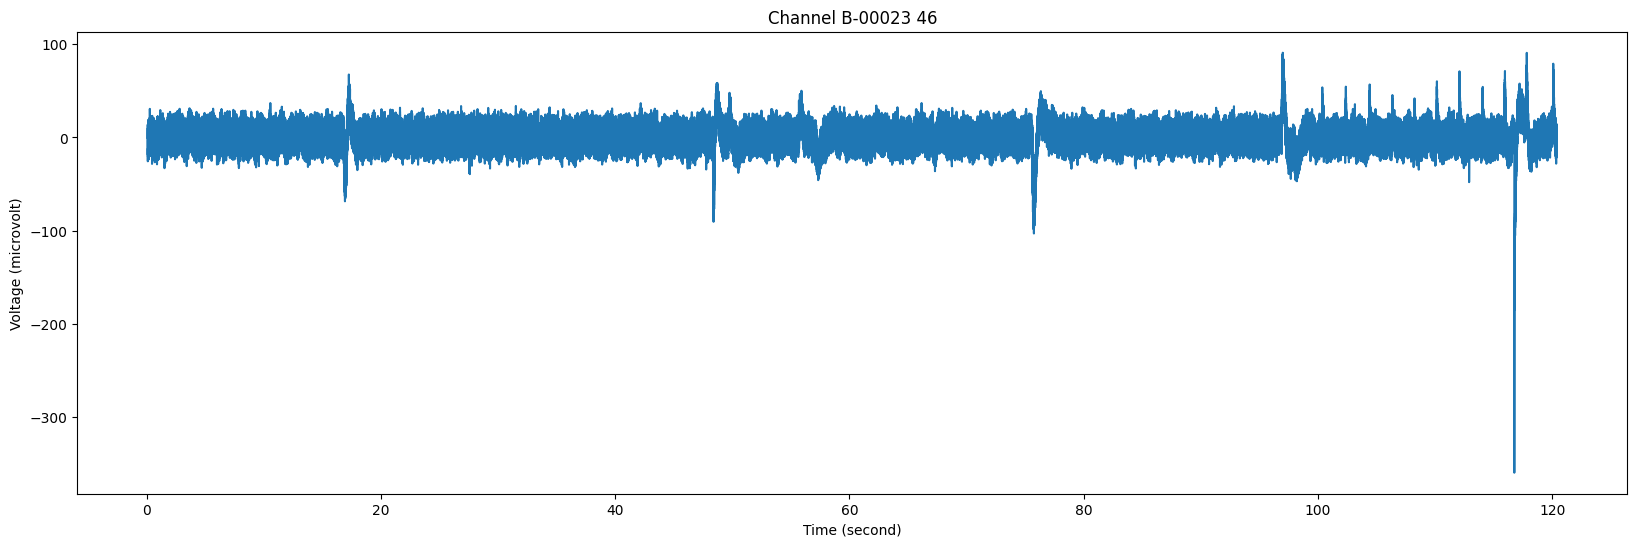

In [39]:
# Check the analog stream of the electrode in channel 0
plot_analog_stream_channel(electrode_stream, channel_idx = 2, from_in_s=0, to_in_s=10000)

c:\Users\Ines\anaconda3\envs\scilife-env\Lib\site-packages\McsPy\McsData.py:534: DeprecationWarning: Calling the getitem method from a UnitRegistry will be removed in future versions of pint.
use `parse_expression` method or use the registry as a callable.


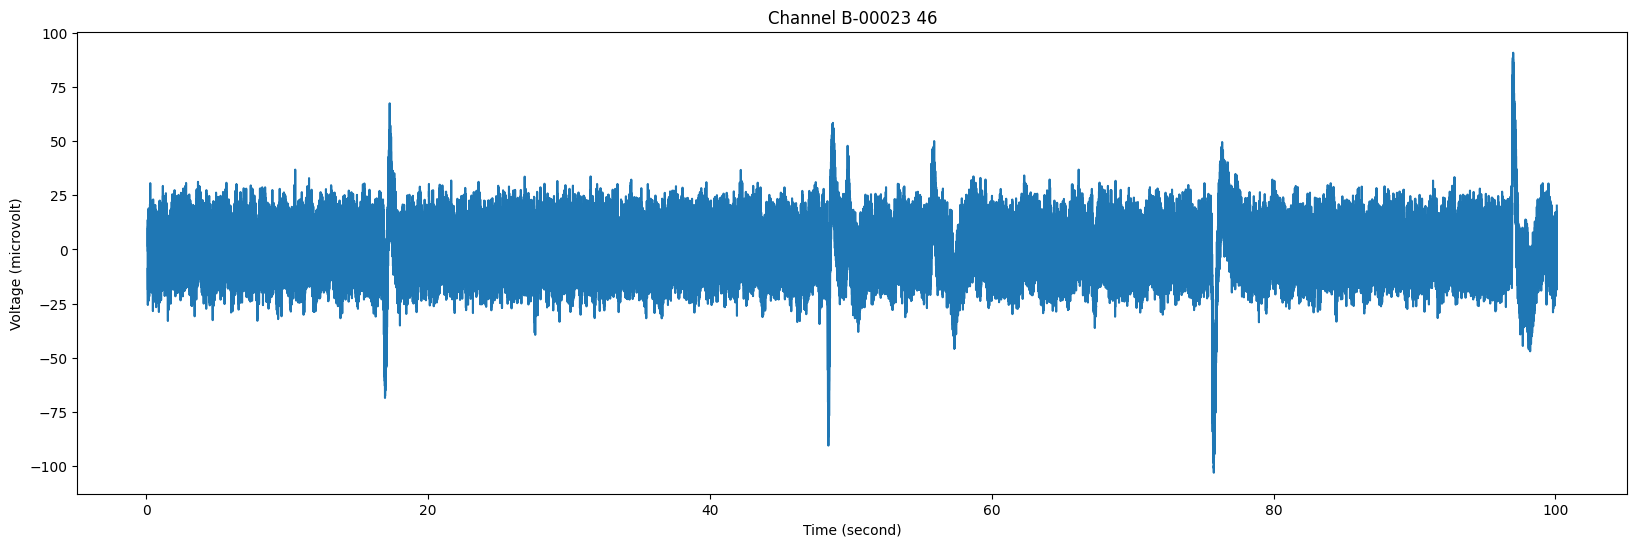

In [44]:
# Check the analog stream of the electrode in channel 0
plot_analog_stream_channel(electrode_stream, channel_idx = 2, from_in_s=0, to_in_s=100)

In [45]:
# Check the bandwidth of the recording to see if
# there have been any filters applied o
channel_id = 2
info = electrode_stream.channel_infos[channel_id].info
print("Bandwidth: %s - %s Hz" % (info['HighPassFilterCutOffFrequency'], info['LowPassFilterCutOffFrequency']))

signal = electrode_stream.get_channel_in_range(channel_id, 0, electrode_stream.channel_data.shape[1])[0]

Bandwidth: -1 - -1 Hz


In [46]:
electrode_stream.channel_infos[0]
fs = (getattr(electrode_stream.channel_infos[0], 'sampling_frequency')) 


<ChannelInfo channel_id=0, row_index=0, sampling_frequency=20000.0 hertz>

In [47]:
type(fs.magnitude)

numpy.float64

In [48]:
# Filter signal
filtered_signal = lowpass_filter(signal, int(fs.magnitude), 50)


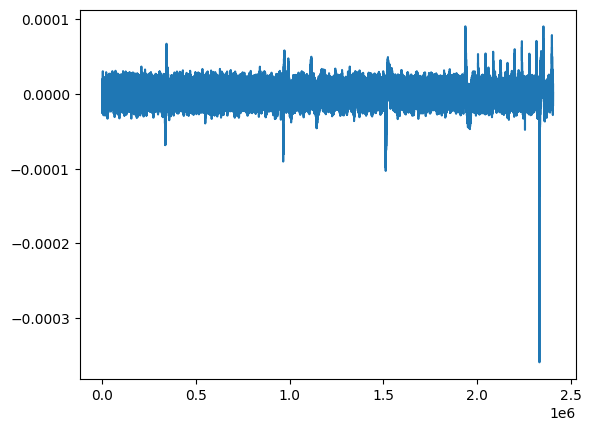

In [49]:
plt.plot(signal)

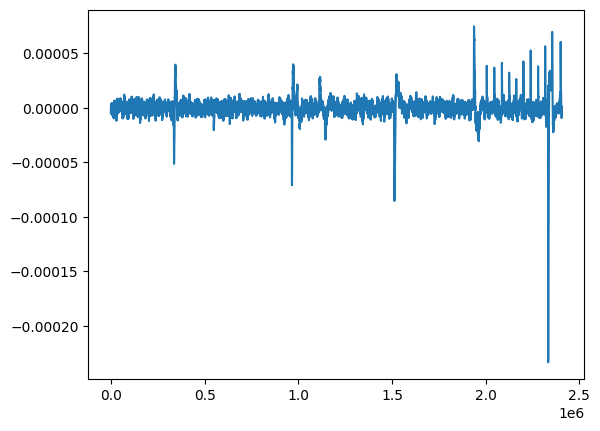

In [80]:
plt.plot(filtered_signal)

In [81]:
# Determine suitable threshold for spike detection
noise_std = np.std(filtered_signal)
noise_mad = np.median(np.absolute(filtered_signal)) / 0.6745
print('Noise Estimate by Standard Deviation: {0:g} V'.format(noise_std))
print('Noise Estimate by MAD Estimator     : {0:g} V'.format(noise_mad))

Noise Estimate by Standard Deviation: 8.97648e-06 V
Noise Estimate by MAD Estimator     : 4.32682e-06 V


In [82]:
spike_threshold = -3.75 * noise_mad # roughly -30 µV

c:\Users\Ines\anaconda3\envs\scilife-env\Lib\site-packages\McsPy\McsData.py:534: DeprecationWarning: Calling the getitem method from a UnitRegistry will be removed in future versions of pint.
use `parse_expression` method or use the registry as a callable.


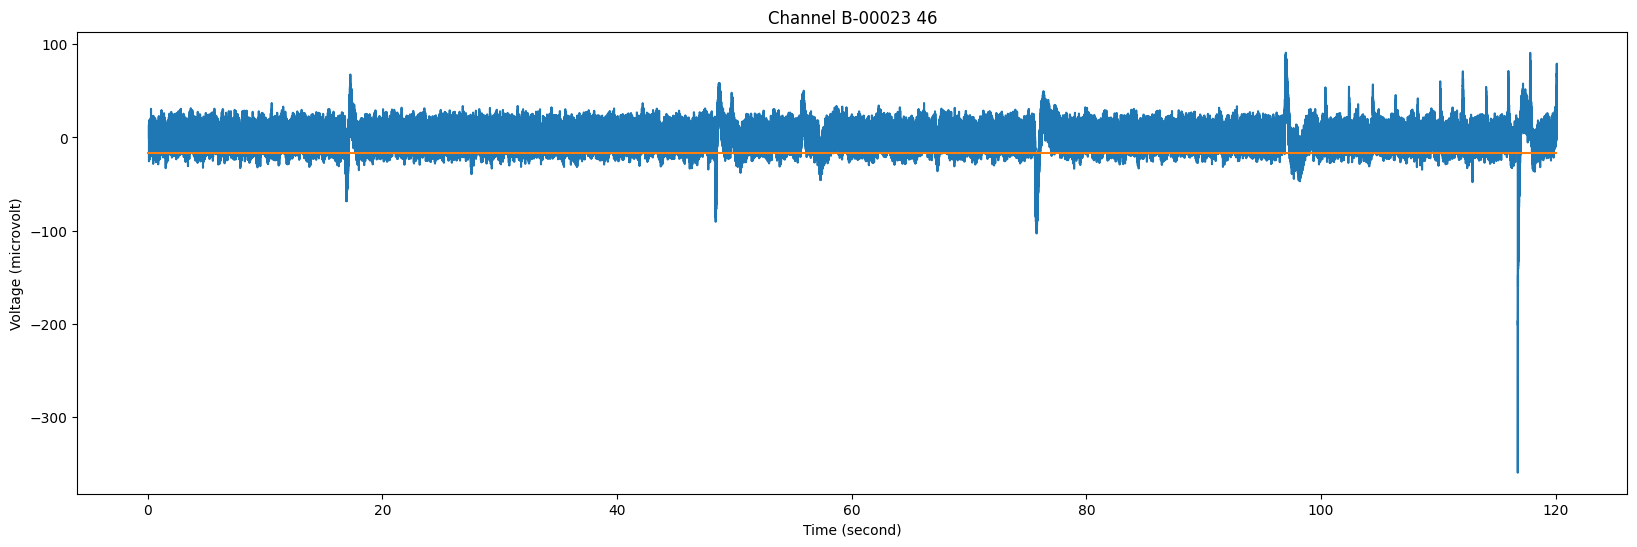

In [83]:
# Plot the data with the spike threshold
plot_analog_stream_channel(electrode_stream, 2, from_in_s=0, to_in_s=120, show=False)

plt.plot([0, 120], [spike_threshold*1e6, spike_threshold*1e6]) # converts the threshold to µV for plotting
plt.show()

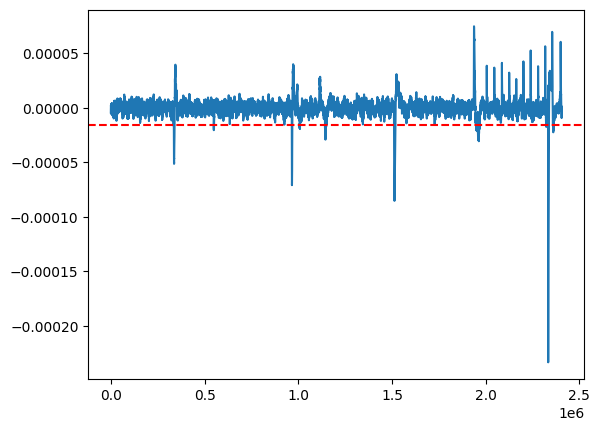

In [84]:
plt.plot(filtered_signal)
# Adding a horizontal line at y=5
plt.axhline(y=spike_threshold, color='r', linestyle='--', label='threshold')



In [85]:
fs = int(electrode_stream.channel_infos[channel_id].sampling_frequency.magnitude)
crossings_neg = detect_threshold_crossings(filtered_signal, fs, spike_threshold, 0.003) # dead time of 3 ms
crossings_pos = detect_threshold_crossings(filtered_signal, fs, -spike_threshold, 0.003) # dead time of 3 ms
crossings = np.concatenate((crossings_neg, crossings_pos)) 

In [86]:
crossings

array([ 335158,  335230,  335840,  339820,  548852,  549637,  549884,
        550120,  965189,  968040, 1007208, 1007273, 1007518, 1007816,
       1008226, 1008504, 1008649, 1008916, 1142394, 1142640, 1145905,
       1145972, 1147521, 1148187, 1148428, 1510659, 1517667, 1948591,
       1948974, 1949046, 1949468, 1949900, 1950077, 1950240, 1951668,
       1953578, 1953771, 1954787, 1954986, 1955061, 1955337, 1955433,
       1958213, 1965990, 1966238, 1966565, 1966902, 1967143, 2322964,
       2323391, 2333297, 2336964, 2358791, 2358884, 2360023, 2361482,
       2362028, 2362289, 2362434, 2362644,  341393,  347123,  347231,
        347854,  349726,  969319,  975973,  992908,  993076,  993281,
        995582, 1112216, 1117497, 1117668, 1117994, 1521656, 1521982,
       1522103, 1522312, 1522480, 1527973, 1528136, 1528266, 1528537,
       1531160, 1531251, 1532349, 1532801, 1534003, 1534515, 1534643,
       1936473, 1942809, 2005327, 2006199, 2006310, 2006486, 2045498,
       2046533, 2086

In [87]:
spks = align_to_minimum(filtered_signal, fs, crossings, 0.002) # search range 2 ms

In [88]:
timestamps = spks / fs
range_in_s = (0, 120)
spikes_in_range = timestamps[(timestamps >= range_in_s[0]) & (timestamps <= range_in_s[1])]


In [89]:
spikes_in_range

array([ 16.75975,  16.7615 ,  16.79395,  16.991  ,  27.44455,  27.48185,
        27.49615,  27.506  ,  48.2614 ,  48.402  ,  50.36205,  50.36365,
        50.37785,  50.3908 ,  50.41325,  50.4252 ,  50.4344 ,  50.4458 ,
        57.12165,  57.132  ,  57.29525,  57.30055,  57.37605,  57.4113 ,
        57.4214 ,  75.5349 ,  75.88335,  97.4308 ,  97.4505 ,  97.4523 ,
        97.47535,  97.495  ,  97.5058 ,  97.512  ,  97.58535,  97.6789 ,
        97.6905 ,  97.73935,  97.7512 ,  97.75305,  97.7688 ,  97.77165,
        97.9126 ,  98.2995 ,  98.31385,  98.32825,  98.34705,  98.35715,
       116.15015, 116.16955, 116.6668 , 116.8482 , 117.9415 , 117.9442 ,
       118.0031 , 118.0741 , 118.10335, 118.11445, 118.12365, 118.1322 ,
        17.06965,  17.3581 ,  17.36155,  17.39465,  17.48825,  48.46595,
        48.8006 ,  49.6454 ,  49.65575,  49.66405,  49.78105,  55.6108 ,
        55.8768 ,  55.8834 ,  55.90165,  76.0828 ,  76.10105,  76.10515,
        76.11755,  76.124  ,  76.4006 ,  76.4068 , 

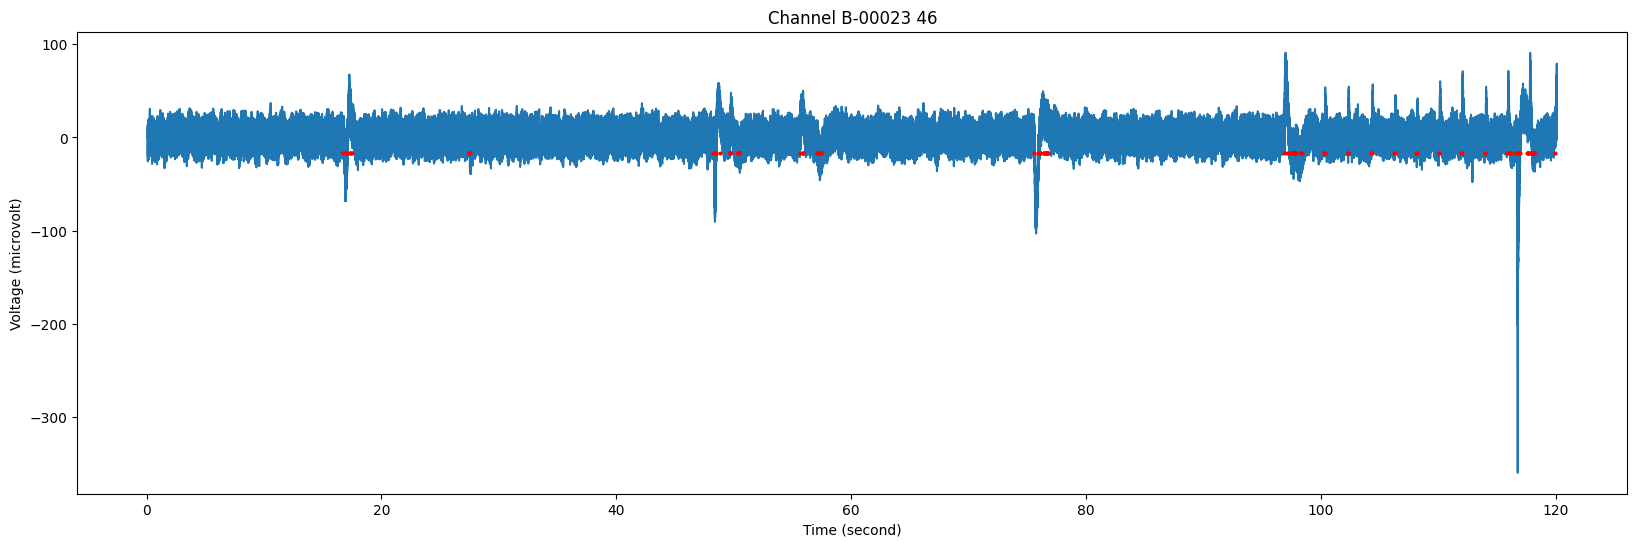

In [90]:

plot_analog_stream_channel(electrode_stream, channel_idx = 2, from_in_s=0, to_in_s=120, show=False)
plt.plot(spikes_in_range, [spike_threshold*1e6]*spikes_in_range.shape[0], 'ro', ms=2)
plt.show()

Text(0.5, 0, 'Time (s)')

Text(0, 0.5, 'Voltage (V)')

Text(0.5, 1.0, 'Detected Spikes')

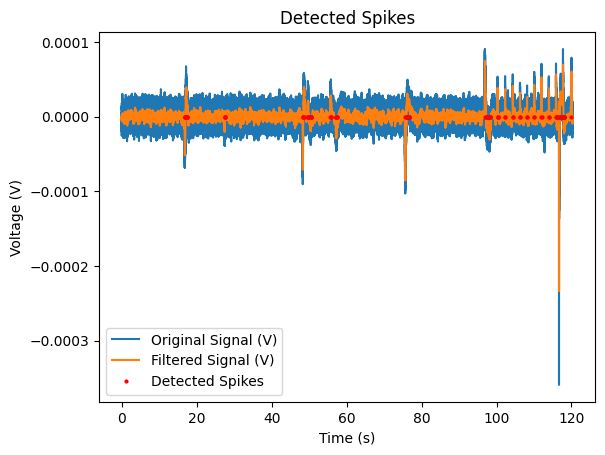

In [91]:

duration = electrode_stream.channel_data.shape[1]/fs
t = np.arange(0, duration, 1/fs)
plt.plot(t,signal, label = "Original Signal (V)")

plt.plot(t,filtered_signal, label='Filtered Signal (V)')

plt.plot(spikes_in_range, [0]*spikes_in_range.shape[0], 'ro', ms=2, label = "Detected Spikes")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Detected Spikes")
plt.legend()



plt.show()

Text(0.5, 1.0, 'Output raster')

Text(0.5, 0, 'Time (s)')

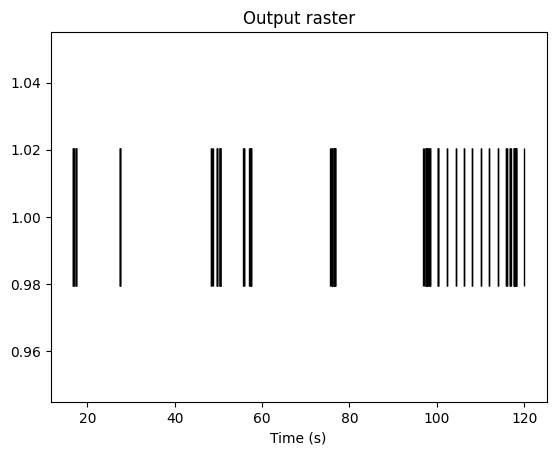

In [92]:
# plot spike train
plt.plot(spikes_in_range, np.ones_like(spikes_in_range), '|', markersize=100, color='black')
plt.title('Output raster')
plt.xlabel('Time (s)')


In [93]:
pre = 0.002 # 1 ms
post= 0.003 # 2 ms
cutouts = extract_waveforms(signal, fs, spks, pre, post)
print("Cutout array shape: " + str(cutouts.shape)) # number of spikes x number of samples

Cutout array shape: (124, 100)


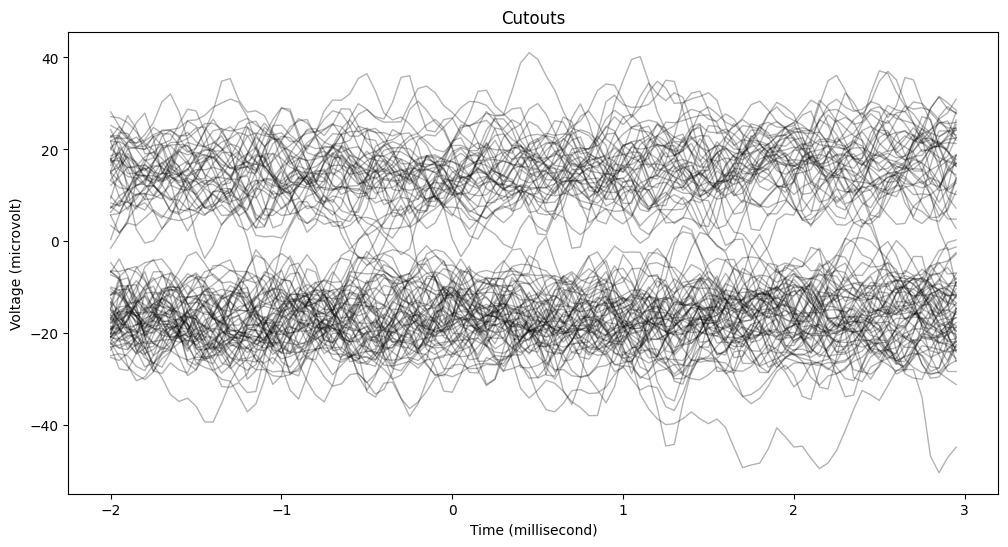

In [95]:
plot_waveforms(cutouts, fs, pre, post, n=100)

Crosscorrelations 

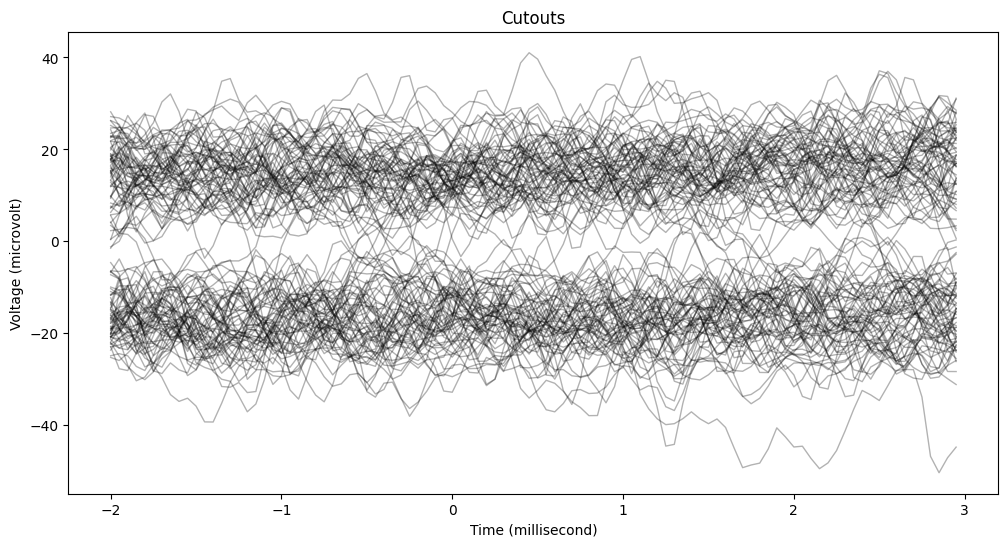

In [96]:
plot_waveforms(cutouts, fs, pre, post, n = 480)


In [126]:
# len(cutouts)

482

Analysis with PCA

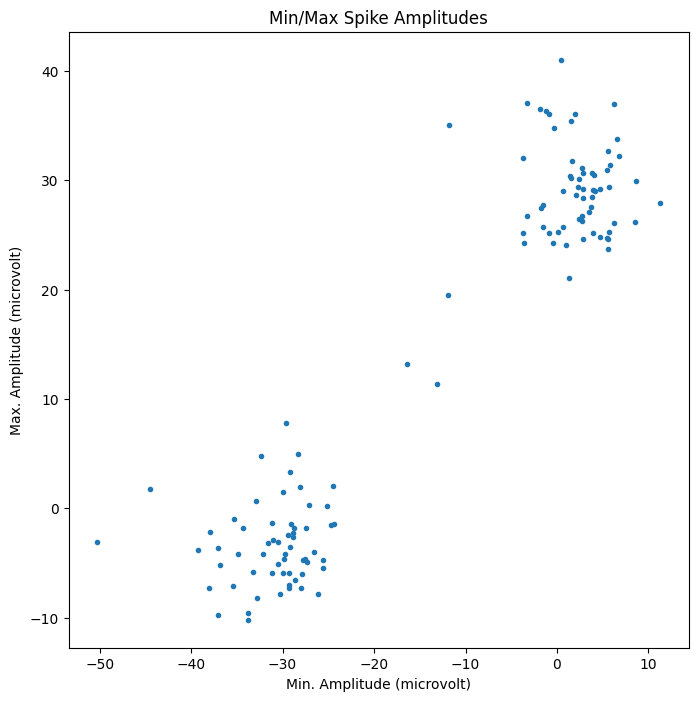

In [97]:
min_amplitude = np.amin(cutouts, axis=1)
max_amplitude = np.amax(cutouts, axis=1)

_ = plt.figure(figsize=(8,8))
_ = plt.plot(min_amplitude*1e6, max_amplitude*1e6,'.')
_ = plt.xlabel('Min. Amplitude (%s)' % ureg.uV)
_ = plt.ylabel('Max. Amplitude (%s)' % ureg.uV)
_ = plt.title('Min/Max Spike Amplitudes')

plt.show()

In [130]:
scaler = StandardScaler()
scaled_cutouts = scaler.fit_transform(cutouts)

pca = PCA()
pca.fit(scaled_cutouts)
print(pca.explained_variance_ratio_)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


[8.94315268e-01 5.93041725e-02 7.87606224e-03 4.72776695e-03
 4.54096551e-03 2.76657912e-03 2.62344127e-03 1.99132145e-03
 1.83540277e-03 1.71442516e-03 1.56248966e-03 1.26710102e-03
 1.09619603e-03 1.07317424e-03 1.01479547e-03 9.38397312e-04
 8.65156645e-04 8.14825265e-04 7.75284412e-04 7.24158057e-04
 6.15952146e-04 5.77587473e-04 5.50063161e-04 5.15452908e-04
 4.87081432e-04 4.43776871e-04 4.05111601e-04 3.79660327e-04
 3.71065180e-04 3.39970665e-04 3.32486859e-04 2.93738450e-04
 2.51877193e-04 2.39225492e-04 2.20467363e-04 1.93852402e-04
 1.87075508e-04 1.66859186e-04 1.46575119e-04 1.33103723e-04
 1.26639435e-04 1.20500345e-04 1.00546996e-04 9.74624712e-05
 9.38811293e-05 7.66570616e-05 7.23313005e-05 6.47333569e-05
 5.86012944e-05 4.91101976e-05 4.85144637e-05 4.40768152e-05
 3.79507287e-05 3.26393055e-05 3.06435419e-05 2.84357446e-05
 2.69861797e-05 2.28193971e-05 2.09630990e-05 1.88398281e-05
 1.66064003e-05 1.35433878e-05 1.26379941e-05 1.07220861e-05
 9.27615383e-06 8.789840

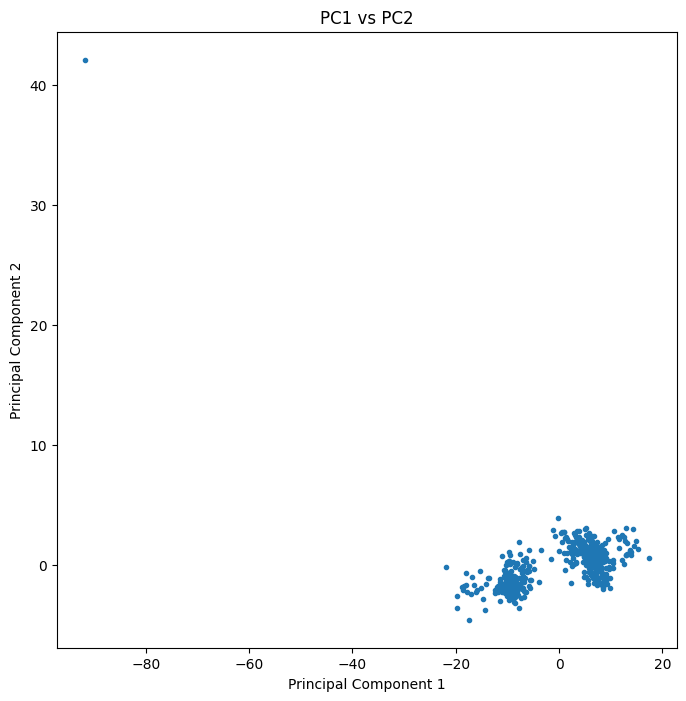

In [131]:
pca.n_components = 2
transformed = pca.fit_transform(scaled_cutouts)

_ = plt.figure(figsize=(8,8))
_ = plt.plot(transformed[:,0], transformed[:,1],'.')
_ = plt.xlabel('Principal Component 1')
_ = plt.ylabel('Principal Component 2')
_ = plt.title('PC1 vs PC2')

plt.show()

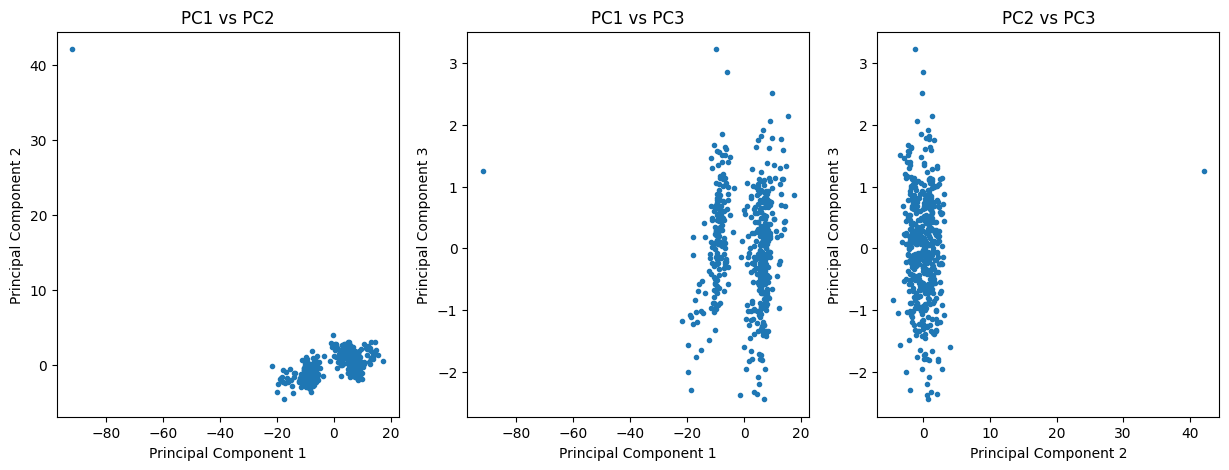

In [132]:
pca.n_components = 3
transformed_3d = pca.fit_transform(scaled_cutouts)

_ = plt.figure(figsize=(15,5))
_ = plt.subplot(1, 3, 1)
_ = plt.plot(transformed_3d[:,0], transformed_3d[:,1],'.')
_ = plt.xlabel('Principal Component 1')
_ = plt.ylabel('Principal Component 2')
_ = plt.title('PC1 vs PC2')
_ = plt.subplot(1, 3, 2)
_ = plt.plot(transformed_3d[:,0], transformed_3d[:,2],'.')
_ = plt.xlabel('Principal Component 1')
_ = plt.ylabel('Principal Component 3')
_ = plt.title('PC1 vs PC3')
_ = plt.subplot(1, 3, 3)
_ = plt.plot(transformed_3d[:,1], transformed_3d[:,2],'.')
_ = plt.xlabel('Principal Component 2')
_ = plt.ylabel('Principal Component 3')
_ = plt.title('PC2 vs PC3')
plt.show()

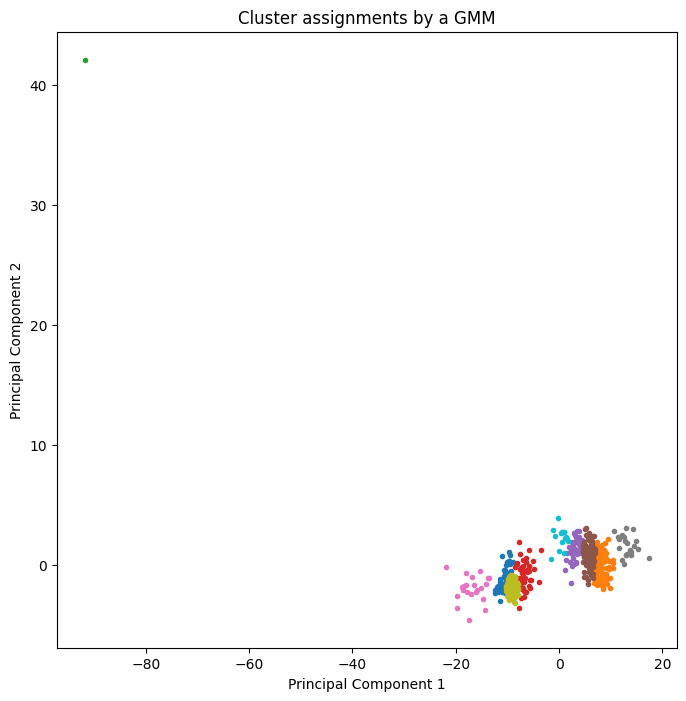

In [134]:
# Clustering
n_components = 10
gmm = GaussianMixture(n_components=n_components, n_init=10)
labels = gmm.fit_predict(transformed)

_ = plt.figure(figsize=(8,8))
for i in range(n_components):
    idx = labels == i
    _ = plt.plot(transformed[idx,0], transformed[idx,1],'.')
    _ = plt.title('Cluster assignments by a GMM')
    _ = plt.xlabel('Principal Component 1')
    _ = plt.ylabel('Principal Component 2')
    _ = plt.axis('tight')
plt.show()

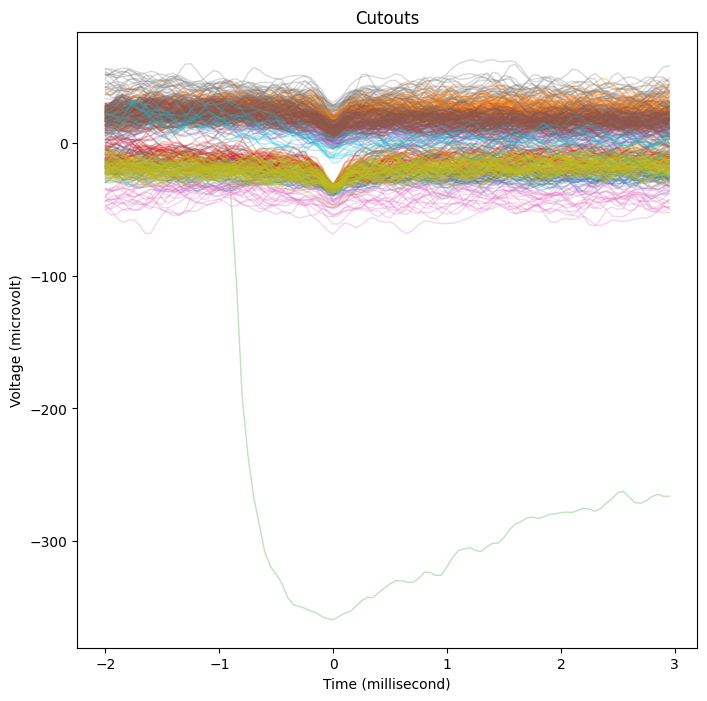

In [135]:
_ = plt.figure(figsize=(8,8))
for i in range(n_components):
    idx = labels == i
    color = plt.rcParams['axes.prop_cycle'].by_key()['color'][i]
    plot_waveforms(cutouts[idx,:], fs, pre, post, n=100, color=color, show=False)
plt.show()

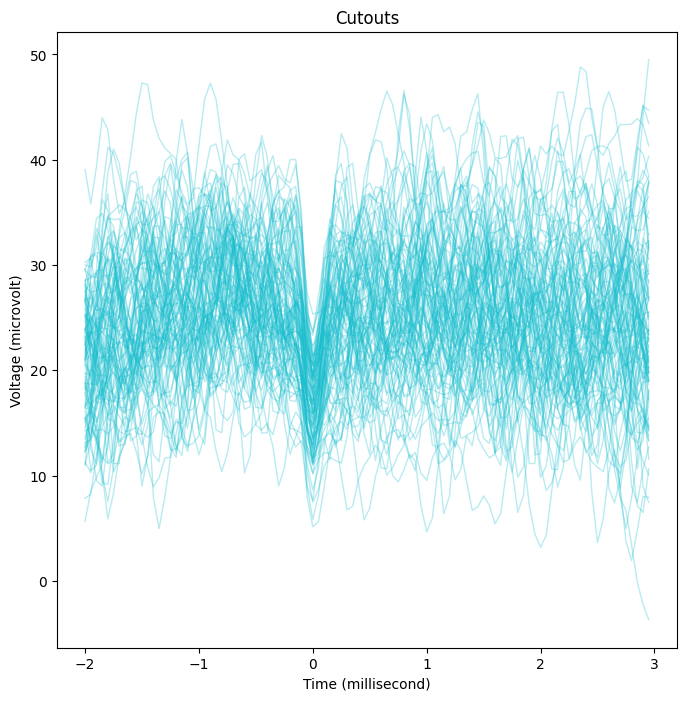

In [143]:
_ = plt.figure(figsize=(8,8))

idx = labels == 1
color = plt.rcParams['axes.prop_cycle'].by_key()['color'][i]
plot_waveforms(cutouts[idx,:], fs, pre, post, n = 200, color=color, show=False)
plt.show()